### Frozen Layer Fine tuning

first two layers of the Organic Teacher have learned "Fundamental Chemistry" (universal rules about atoms and bonds) that are identical for both small molecules and polymers. By freezing these layers, we prevent the polymer data from "corrupting" this fundamental knowledge, while allowing the deeper layers to specialize in polymer-specific biodegradation.

### Cell 1: GPU Availability Check

In [1]:
import torch
import os

# Select the specific GPU
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"✅ Using Device: {device}")

✅ Using Device: cuda:3


### Cell 2: IMPORTS AND GLOBAL CONFIGURATIONS
We update the paths to point to your Fewshot_DNN_Model folder.

In [2]:
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import time
import joblib
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader

# Update paths for Fewshot approach
PATHS = {
    "weights": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Fewshot_DNN_Model/master_mol_dnn_model.pth",
    "params": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Fewshot_DNN_Model/mol_dnn_optuna_best_study.pkl",
    "data": "/home/sunil/am2/poetry-demo/AM2_Poly_biodegradebilty_Cluster/DNN_Models/Fewshot_DNN_Model/POL_DNN_processed.pt",
    "output_dir": "plots_fewshot_frozen"
}

if not os.path.exists(PATHS["output_dir"]): 
    os.makedirs(PATHS["output_dir"])

print("✅ Imports complete and paths configured for Fewshot learning.")

✅ Imports complete and paths configured for Fewshot learning.


/home/sunil/.cache/pypoetry/virtualenvs/poetry-demo-9b10jFFD-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Cell 3: DEFINE YOUR DNN MODEL CLASS
This is the same DynamicNet structure, which is required to load your pre-trained weights.

In [3]:
def get_activation(name, nodes=None):
    if name == "ReLU": return nn.ReLU()
    if name == "Mish": return nn.Mish()
    if name == "SiLU": return nn.SiLU()
    if name == "PReLU": return nn.PReLU(num_parameters=nodes)
    return nn.ReLU()

class DynamicNet(nn.Module):
    def __init__(self, input_dim, layers, dropout_rate, activation_name):
        super(DynamicNet, self).__init__()
        all_layers = []
        curr_dim = input_dim
        for nodes in layers:
            all_layers.append(nn.Linear(curr_dim, nodes))
            all_layers.append(nn.BatchNorm1d(nodes))
            all_layers.append(get_activation(activation_name, nodes))
            all_layers.append(nn.Dropout(dropout_rate))
            curr_dim = nodes
        all_layers.append(nn.Linear(curr_dim, 1))
        self.model = nn.Sequential(*all_layers)
        
    def forward(self, x):
        return self.model(x)

print("✅ DynamicNet class defined.")

✅ DynamicNet class defined.


### Cell 4: DEFINE DATASET CLASS

In [4]:
class MolDataset(Dataset):
    def __init__(self, fps, time, targets):
        self.features = torch.cat([torch.tensor(fps), torch.tensor(time).unsqueeze(1)], dim=1).float()
        self.targets = torch.tensor(targets).float().unsqueeze(1)
    def __len__(self): return len(self.targets)
    def __getitem__(self, idx): return self.features[idx], self.targets[idx]

print("✅ MolDataset class defined.")

✅ MolDataset class defined.


### Cell 5: DEFINE ALL UTILITY FUNCTIONS
These functions will handle the metrics and plotting for the final comparison.

In [5]:
def calculate_metrics(actuals, preds):
    r2 = r2_score(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    return r2, rmse, mae

def plot_parity(actuals, preds, title="Parity Plot", save_name="plot.png"):
    r2, rmse, mae = calculate_metrics(actuals, preds)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actuals, y=preds, alpha=0.6, color='darkorange')
    plt.plot([0, 1], [0, 1], 'k--', label="Perfect Match")
    plt.title(f"{title}\n(R²: {r2:.3f}, MAE: {mae:.3f})")
    plt.xlabel("Actual Biodegradation")
    plt.ylabel("Predicted Biodegradation")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.savefig(os.path.join(PATHS["output_dir"], save_name), dpi=300)
    plt.show()

print("✅ Utility functions defined.")

✅ Utility functions defined.


### Cell 6: DATA LOADING AND NOBLE SPLIT
We perform the same 80/20 split on the polymer data to maintain consistency across all three approaches.

In [6]:
# 1. Load the Polymer Data
poly_bundle = torch.load(PATHS["data"], map_location='cpu')
p_fps = poly_bundle['fingerprints'].numpy()
p_time = poly_bundle['time_day'].numpy()
p_targets = poly_bundle['biodegradation'].numpy()

# 2. Perform the Noble Split (80/20)
indices = np.arange(len(p_fps))
train_val_idx, noble_test_idx = train_test_split(
    indices, test_size=0.20, random_state=42, shuffle=True
)

train_val_poly = {
    'fps': p_fps[train_val_idx],
    'time': p_time[train_val_idx],
    'targets': p_targets[train_val_idx]
}

noble_test_poly = {
    'fps': p_fps[noble_test_idx],
    'time': p_time[noble_test_idx],
    'targets': p_targets[noble_test_idx]
}

print(f"📖 Loaded {len(p_fps)} Polymer points.")
print(f"🏋️ Training/CV Pool: {len(train_val_idx)} polymers.")
print(f"💎 Noble Test Set: {len(noble_test_idx)} polymers (Reserved).")

📖 Loaded 80 Polymer points.
🏋️ Training/CV Pool: 64 polymers.
💎 Noble Test Set: 16 polymers (Reserved).


By freezing the first two layers (the first 8 modules of the sequential model), we ensure that the model's basic understanding of chemical features remains intact. We then allow Optuna to find the best way to train the remaining "specialized" layers to handle polymer-specific biodegradation.

### Cell 7: DEFINE OPTUNA OBJECTIVE FUNCTION (Frozen Layers)

In [7]:
# Cell 7: DEFINE OPTUNA OBJECTIVE FUNCTION (Frozen Layers)
def objective(trial):
    # 1. Load the Teacher's Architecture
    mol_study = joblib.load(PATHS["params"])
    t_params = mol_study.best_params
    n_layers = t_params['n_layers']
    layers = [t_params[f'n_units_l{i}'] for i in range(n_layers)]
    activation_name = t_params['activation']
    
    # 2. Suggested Hyperparameters for Fine-Tuning the "Unfrozen" layers
    # We use a lower LR range as requested for fine-tuning
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    batch_size = 16

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_r2 = []

    for fold, (t_idx, v_idx) in enumerate(kf.split(train_val_poly['fps'])):
        # Data Setup
        t_ds = MolDataset(train_val_poly['fps'][t_idx], train_val_poly['time'][t_idx], train_val_poly['targets'][t_idx])
        v_ds = MolDataset(train_val_poly['fps'][v_idx], train_val_poly['time'][v_idx], train_val_poly['targets'][v_idx])
        train_loader = DataLoader(t_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(v_ds, batch_size=batch_size)

        # 3. RECONSTRUCT & LOAD WEIGHTS
        model = DynamicNet(601, layers, dropout, activation_name).to(device)
        state_dict = torch.load(PATHS["weights"], map_location=device)
        model.load_state_dict(state_dict, strict=False)

        # --- LAYER FREEZING LOGIC ---
        # In our DynamicNet: Each layer = Linear + BatchNorm + Activation + Dropout (4 modules)
        # To freeze the first TWO layers, we freeze the first 8 modules
        modules_to_freeze = 8
        child_counter = 0
        for child in model.model.children():
            if child_counter < modules_to_freeze:
                for param in child.parameters():
                    param.requires_grad = False
            child_counter += 1
        
        # 4. Optimizer: Only update parameters that are NOT frozen
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), 
            lr=lr, 
            weight_decay=weight_decay
        )
        criterion = nn.MSELoss()

        # 5. Fine-Tuning with Early Stopping
        best_v_loss = float('inf')
        patience = 15
        trigger = 0

        for epoch in range(150): # Lower max epochs for fine-tuning
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

            # Validation
            model.eval()
            v_loss = 0
            with torch.no_grad():
                for bx, by in val_loader:
                    v_loss += criterion(model(bx.to(device)), by.to(device)).item()
            
            avg_v_loss = v_loss / len(val_loader)
            if avg_v_loss < best_v_loss:
                best_v_loss = avg_v_loss
                trigger = 0
            else:
                trigger += 1
            if trigger >= patience: break
        
        # Fold Eval
        model.eval()
        p, a = [], []
        with torch.no_grad():
            for bx, by in val_loader:
                p.extend(model(bx.to(device)).cpu().numpy().flatten())
                a.extend(by.numpy().flatten())
        
        fold_r2.append(r2_score(a, p))
        
        # Pruning
        trial.report(np.mean(fold_r2), fold)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()

    return np.mean(fold_r2)

print("🎯 Frozen-Layer Objective defined (First 2 layers freezed).")

🎯 Frozen-Layer Objective defined (First 2 layers freezed).


### Cell 7.1: Optuna Hyperparameter Optimization Execution

In [8]:
import optuna
from tqdm.auto import tqdm
import logging
import time
import joblib

# 1. Suppress the default Optuna trial logs for a clean output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 2. Define the Study-Level Early Stopping Callback
class EarlyStoppingCallback:
    def __init__(self, early_stopping_rounds: int):
        self.early_stopping_rounds = early_stopping_rounds
        self._best_value = -float('inf')
        self._wait = 0

    def __call__(self, study, trial):
        try:
            current_best = study.best_value
        except ValueError:
            return

        if current_best > self._best_value:
            self._best_value = current_best
            self._wait = 0
        else:
            self._wait += 1
            if self._wait >= self.early_stopping_rounds:
                print(f"\n🛑 Study-level Early Stopping: No improvement in {self.early_stopping_rounds} trials.")
                study.stop()

# 3. Create the study with a MedianPruner
# This "prunes" (kills) trials that are clearly underperforming after the first few folds
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())

# 4. Run Optimization with Timing
n_trials = 1000
print(f"🚀 Starting {n_trials} Optimization Trials (Frozen-Layer Transfer Learning)...")
start_time = time.time()

# Optimize using the custom early stopping (100 rounds)
study.optimize(
    objective, 
    n_trials=n_trials, 
    show_progress_bar=True,
    callbacks=[EarlyStoppingCallback(early_stopping_rounds=100)]
)

elapsed_time = time.time() - start_time
print(f"\n✨ Optimization Finished in {elapsed_time/60:.2f} minutes!")

# 5. Display the Top 20 Trials Leaderboard
print("\n🏆 TOP 20 FROZEN-LAYER FINE-TUNING TRIALS:")
trials_df = study.trials_dataframe()

top_20 = trials_df.sort_values(by="value", ascending=False).head(20)
cols_to_show = ['number', 'value'] + [c for c in top_20.columns if c.startswith('params_')]
print(top_20[cols_to_show].to_string(index=False))

# 6. Best Trial Summary
print("\n" + "="*50)
print(f"🥇 BEST FROZEN-LAYER TRIAL: #{study.best_trial.number}")
print(f"📊 Best CV R2 Score: {study.best_value:.6f}")
print(f"🛠️ Best Params: {study.best_params}")
print("="*50)

# 7. Save the study results (Unique name for Approach 3)
study_filename = os.path.join(PATHS["output_dir"], "fewshot_frozen_optuna_study.pkl")
joblib.dump(study, study_filename)
print(f"💾 Study results saved as: {study_filename}")

🚀 Starting 1000 Optimization Trials (Frozen-Layer Transfer Learning)...


Best trial: 26. Best value: 0.768663:  13%|█▎        | 127/1000 [02:11<15:05,  1.04s/it]


🛑 Study-level Early Stopping: No improvement in 100 trials.

✨ Optimization Finished in 2.20 minutes!

🏆 TOP 20 FROZEN-LAYER FINE-TUNING TRIALS:
 number    value  params_dropout  params_lr  params_weight_decay
     91 0.768751        0.351109   0.000279             0.000009
    124 0.768716        0.355174   0.000387             0.000028
     26 0.768663        0.342325   0.000356             0.000070
    103 0.767393        0.163575   0.000158             0.000002
     74 0.767093        0.389774   0.000213             0.000055
     93 0.766128        0.343188   0.000403             0.000060
     90 0.762151        0.387839   0.000366             0.000027
     46 0.758505        0.351565   0.000254             0.000100
     70 0.757982        0.305009   0.000385             0.000012
     53 0.757382        0.309330   0.000438             0.000010
    116 0.756404        0.348409   0.000290             0.000038
     23 0.755931        0.399585   0.000334             0.000047
    104 0

### Cell 7.2: Train Final Transfer Model & 5-Fold CV with Std Dev
This cell performs the final training on the 80% pool and generates the detailed statistical report you need for your thesis tables.

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Setup Architecture and Best Params
best_p = study.best_params
mol_study = joblib.load(PATHS["params"])
t_params = mol_study.best_params
layers = [t_params[f'n_units_l{i}'] for i in range(t_params['n_layers'])]

# 2. Define the 5-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

pool_fps = train_val_poly['fps']
pool_time = train_val_poly['time']
pool_targets = train_val_poly['targets']

print(f"📋 Detailed 5-Fold CV Report: Frozen-Layer Approach")
print("-" * 60)

for fold, (t_idx, v_idx) in enumerate(kf.split(pool_fps)):
    # Prepare Data
    t_ds = MolDataset(pool_fps[t_idx], pool_time[t_idx], pool_targets[t_idx])
    v_ds = MolDataset(pool_fps[v_idx], pool_time[v_idx], pool_targets[v_idx])
    t_loader = DataLoader(t_ds, batch_size=16, shuffle=True)
    v_loader = DataLoader(v_ds, batch_size=16)

    # Initialize and Load Weights
    model = DynamicNet(601, layers, best_p['dropout'], t_params['activation']).to(device)
    model.load_state_dict(torch.load(PATHS["weights"], map_location=device), strict=False)

    # FREEZE first 2 layers (8 modules)
    modules_to_freeze = 8
    for i, child in enumerate(model.model.children()):
        if i < modules_to_freeze:
            for param in child.parameters():
                param.requires_grad = False

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                                 lr=best_p['lr'], weight_decay=best_p['weight_decay'])
    criterion = nn.MSELoss()

    # Train (Lower epochs for frozen fine-tuning)
    model.train()
    for epoch in range(150):
        for bx, by in t_loader:
            optimizer.zero_grad()
            criterion(model(bx.to(device)), by.to(device)).backward()
            optimizer.step()

    # Eval Fold
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for bx, by in v_loader:
            preds.extend(model(bx.to(device)).cpu().numpy().flatten())
            actuals.extend(by.numpy().flatten())
    
    r2 = r2_score(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    fold_results.append((r2, rmse, mae))
    print(f"Fold {fold+1}: R² = {r2:.4f} | RMSE = {rmse:.4f}")

# 3. Final Model Training (On full 80% training pool)
final_frozen_model = DynamicNet(601, layers, best_p['dropout'], t_params['activation']).to(device)
final_frozen_model.load_state_dict(torch.load(PATHS["weights"], map_location=device), strict=False)

# Freeze again for final training
for i, child in enumerate(final_frozen_model.model.children()):
    if i < 8:
        for param in child.parameters(): param.requires_grad = False

full_train_loader = DataLoader(MolDataset(pool_fps, pool_time, pool_targets), batch_size=16, shuffle=True)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, final_frozen_model.parameters()), lr=best_p['lr'])

for epoch in range(150):
    for bx, by in full_train_loader:
        optimizer.zero_grad()
        criterion(final_frozen_model(bx.to(device)), by.to(device)).backward()
        optimizer.step()

torch.save(final_frozen_model.state_dict(), "final_frozen_transfer_model.pth")

# 4. Summary Statistics
avg_r2, std_r2 = np.mean([f[0] for f in fold_results]), np.std([f[0] for f in fold_results])
avg_rmse, std_rmse = np.mean([f[1] for f in fold_results]), np.std([f[1] for f in fold_results])
avg_mae, std_mae = np.mean([f[2] for f in fold_results]), np.std([f[2] for f in fold_results])

print("\n" + "="*50)
print("FINAL 5-FOLD CROSS-VALIDATION RESULTS (Approach 3)")
print(f" R²:   {avg_r2:.4f} (±{std_r2:.4f})")
print(f" RMSE: {avg_rmse:.4f} (±{std_rmse:.4f})")
print(f" MAE:  {avg_mae:.4f} (±{std_mae:.4f})")
print("="*50)

📋 Detailed 5-Fold CV Report: Frozen-Layer Approach
------------------------------------------------------------
Fold 1: R² = 0.8413 | RMSE = 0.1306
Fold 2: R² = 0.6675 | RMSE = 0.2042
Fold 3: R² = 0.6411 | RMSE = 0.1635
Fold 4: R² = 0.8118 | RMSE = 0.1272
Fold 5: R² = 0.7788 | RMSE = 0.1398

FINAL 5-FOLD CROSS-VALIDATION RESULTS (Approach 3)
 R²:   0.7481 (±0.0795)
 RMSE: 0.1531 (±0.0285)
 MAE:  0.1218 (±0.0217)


### Cell 8: EVALUATE BASE MODEL ON NOBLE TEST SET
This cell tests the final frozen-layer model on your held-out noble set.

💎 Evaluating Final Frozen-Layer Model on 16 Noble Polymers...
🚀 FINAL NOBLE TEST PERFORMANCE (FROZEN LAYERS)
📊 R² Score: 0.7173
📉 RMSE:     0.1853
📏 MAE:      0.1408


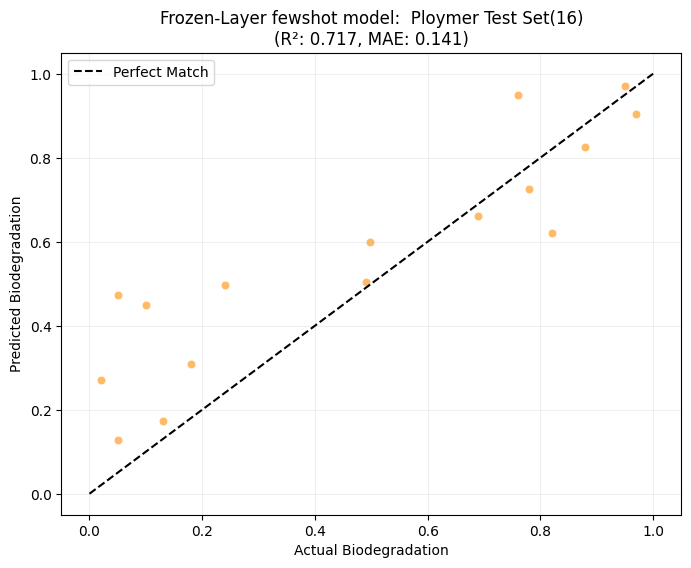

In [15]:
# Cell 9: EVALUATE ON NOBLE TEST SET
print("💎 Evaluating Final Frozen-Layer Model on 16 Noble Polymers...")

# 1. Prepare Noble Data
noble_ds = MolDataset(noble_test_poly['fps'], noble_test_poly['time'], noble_test_poly['targets'])
noble_loader = DataLoader(noble_ds, batch_size=len(noble_ds))

# 2. Prediction
final_frozen_model.eval()
with torch.no_grad():
    for bx, by in noble_loader:
        noble_preds = final_frozen_model(bx.to(device)).cpu().numpy().flatten()
        noble_actuals = by.numpy().flatten()

# 3. Metrics
n_r2, n_rmse, n_mae = calculate_metrics(noble_actuals, noble_preds)


print("🚀 FINAL NOBLE TEST PERFORMANCE (FROZEN LAYERS)")
print(f"📊 R² Score: {n_r2:.4f}")
print(f"📉 RMSE:     {n_rmse:.4f}")
print(f"📏 MAE:      {n_mae:.4f}")


# 4. Parity Plot
plot_parity(noble_actuals, noble_preds, 
            title="Frozen-Layer fewshot model:  Ploymer Test Set(16)", 
            save_name="Fewshot_Frozen_Noble_Parity.png")

### Cell 9: Kinetic Prediction for Noble Polymers (#3, #9, #15)
As requested, we will generate the 28-day OECD-style kinetic curves for specifically chosen noble polymers.

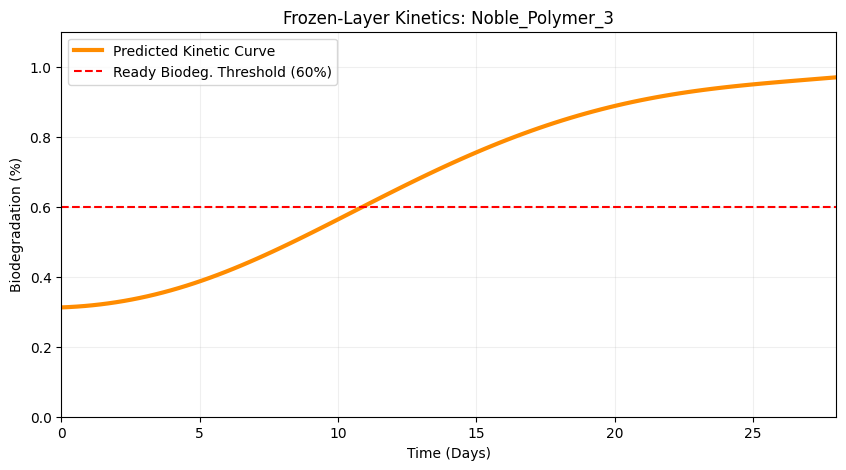

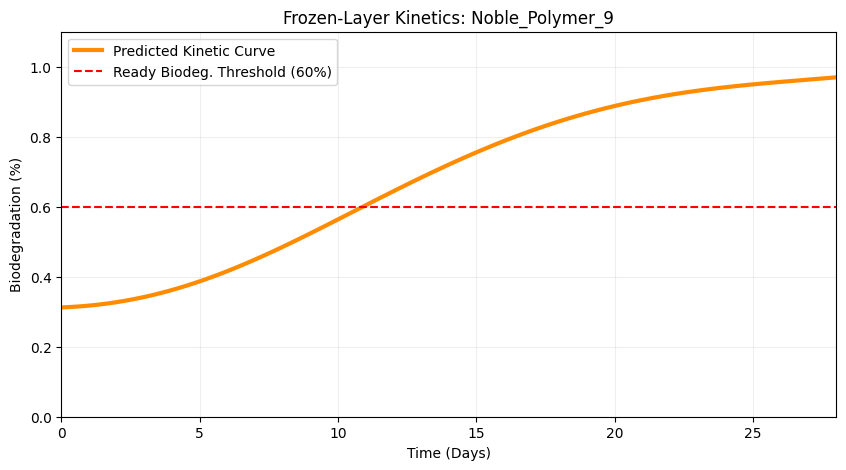

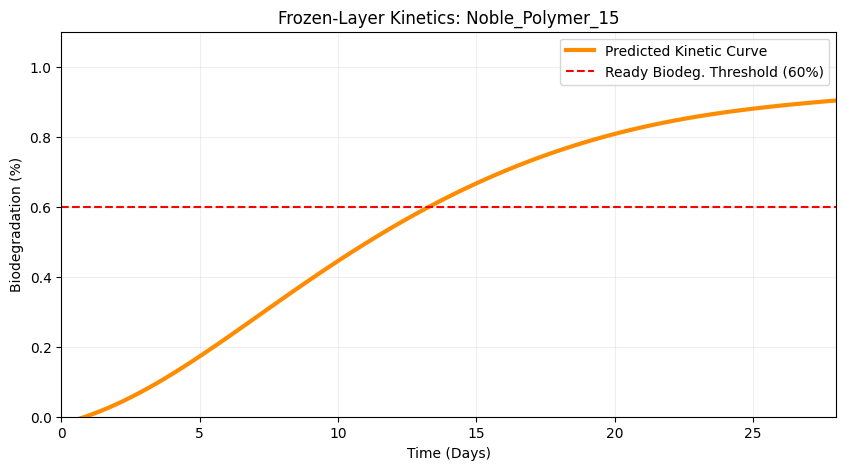

In [16]:
# Cell 8.1: Kinetic Prediction (28-Day OECD Standard)
def plot_kinetic_prediction_frozen(model, fingerprint, molecule_name):
    model.eval()
    days = np.linspace(0, 28, 100) 
    preds = []
    
    with torch.no_grad():
        for d in days:
            feat = torch.cat([
                torch.tensor(fingerprint).float(), 
                torch.tensor([d]).float()
            ]).unsqueeze(0).to(device)
            preds.append(model(feat).cpu().item())
    
    plt.figure(figsize=(10, 5))
    plt.plot(days, preds, color='darkorange', lw=3, label='Predicted Kinetic Curve')
    plt.axhline(y=0.6, color='red', linestyle='--', label='Ready Biodeg. Threshold (60%)')
    
    plt.title(f"Frozen-Layer Kinetics: {molecule_name}")
    plt.xlabel("Time (Days)")
    plt.ylabel("Biodegradation (%)")
    plt.ylim(0, 1.1)
    plt.xlim(0, 28)
    plt.grid(True, alpha=0.2)
    plt.legend()
    
    filename = f"Kinetic_Frozen_{molecule_name}.png"
    plt.savefig(os.path.join(PATHS["output_dir"], filename), dpi=300, bbox_inches='tight')
    plt.show()

# Run specifically for Noble Indices 3, 9, and 15
for idx in [3, 9, 15]:
    # Safety check: ensure index is within the noble test set size
    if idx < len(noble_test_poly['fps']):
        sample_fp = noble_test_poly['fps'][idx]
        plot_kinetic_prediction_frozen(final_frozen_model, sample_fp, f"Noble_Polymer_{idx}")
    else:
        print(f"⚠️ Index {idx} out of range for Noble Set (Size: {len(noble_test_poly['fps'])})")